In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
consts = [((0, 3), 1),
          ((4, 6), 3), ]
steps = [((3, 4), (1, 3)),
         ((6, 8), (3, 2)), ]

In [3]:
x = np.linspace(0, 8, 100)

In [4]:
def piecewise(x, consts, steps):
    y = np.full_like(x, np.nan, dtype=float)

    for (x0, x1), val in consts:
        mask = (x >= x0) & (x < x1)
        y[mask] = val

    for (x0, x1), (v0, v1) in steps:
        mask = (x >= x0) & (x < x1)
        t = (x[mask] - x0) / (x1 - x0)
        y[mask] = v0 + (v1 - v0) * (3*t**2 - 2*t**3)

    return y

In [5]:
y = piecewise(x, consts, steps)

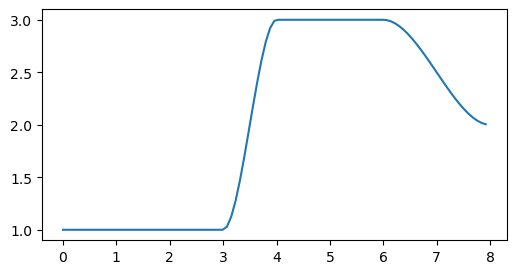

In [6]:
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot()
ax.plot(x,y)

In [18]:
box = [[0, 20], [0, 10]]  # [[xmin, xmax], [ylmin, ymax]]

x0 = box[0][0]
x1 = 0.25*(box[0][1]-box[0][0])
xh = 0.50*(box[0][1]-box[0][0])
x2 = 0.75*(box[0][1]-box[0][0])
xm = box[0][1]

Dx = 1.0

In [19]:
Bs = [-1.0, +1.0]

consts = [((x0,    x1-Dx), Bs[0]),
          ((x1+Dx, x2-Dx), Bs[1]), 
          ((x2+Dx, xm),    Bs[0]), ]
steps = [((x1-Dx, x1+Dx), (Bs[0], Bs[1])),
         ((x2-Dx, x2+Dx), (Bs[1], Bs[0])), ]

In [20]:
x = np.linspace(x0, xm, 200)

In [21]:
y = piecewise(x, consts, steps)

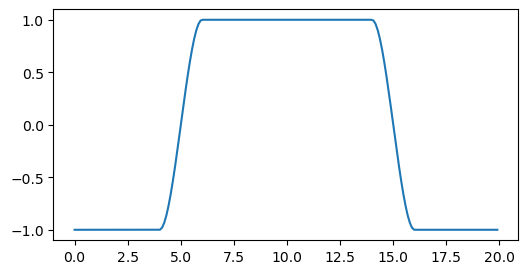

In [22]:
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot()
ax.plot(x,y)